In [1]:
import os
from collections import Counter
from typing import List, Optional, TypedDict

from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import OllamaEmbeddings
from langchain_mongodb import MongoDBAtlasVectorSearch
from pymongo import MongoClient
from langgraph.graph import StateGraph, END

load_dotenv()

f:\Agents\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

#### Pydantic Schema Defination

In [2]:
# ─────────────────────────────────────────────
#  Resume Analysis Models
# ─────────────────────────────────────────────
class SkillContext(BaseModel):
    name: str = Field(description="Normalized skill name (e.g., Python, MongoDB)")
    context: str = Field(description="Specific usage context from the resume")
    level: str = Field(description="Inferred level: Beginner, Intermediate, or Advanced")


class ResumeProfile(BaseModel):
    summary: str = Field(
        description="A 2-sentence professional summary optimized for vector similarity search, "
                    "naming the exact tech stack, experience type, and target domain."
    )
    skills: List[SkillContext] = Field(description="All technical skills with usage context and level.")
    target_roles: List[str] = Field(description="Inferred job titles the candidate is qualified for.")
    seniority_level: str = Field(
        description="Inferred seniority: Intern, Junior, Mid-level, Senior, Lead."
    )


# ─────────────────────────────────────────────
#  Gap Analysis Models
# ─────────────────────────────────────────────
class SkillGap(BaseModel):
    missing_skill: str = Field(description="Canonical name of the skill the candidate lacks.")
    frequency: int = Field(
        description="Number of matched job postings that require this skill."
    )
    importance: str = Field(
        description="'Critical' if core requirement in most jobs, 'Competitive Edge' if specialized."
    )


class GapAnalysisResult(BaseModel):
    critical_gaps: List[SkillGap] = Field(
        description="High-priority missing skills that block candidacy for matched roles."
    )
    nice_to_haves: List[SkillGap] = Field(
        description="Skills that would differentiate the candidate but are not blockers."
    )


# ─────────────────────────────────────────────
#  Roadmap Models
# ─────────────────────────────────────────────
class LearningResource(BaseModel):
    title: str = Field(description="Specific resource name (e.g., 'SQLBolt Interactive Tutorial').")
    url: str = Field(description="Direct URL to the resource.")
    resource_type: str = Field(
        description="One of: Course, Documentation, Practice, Video, Book."
    )
    is_free: bool = Field(description="True if the resource is free.")


class WeeklyTask(BaseModel):
    week_label: str = Field(description="e.g., 'Week 1', 'Weeks 2-3'.")
    topic: str = Field(description="Core concept or module to cover this week.")
    tasks: List[str] = Field(
        description="3-5 specific, actionable tasks for this week (e.g., 'Complete SQLBolt lessons 1-8')."
    )
    milestone: str = Field(
        description="Concrete deliverable or competency checkpoint by end of this period."
    )


class LearningStep(BaseModel):
    skill: str = Field(description="The skill to be acquired.")
    importance: str = Field(description="'Critical Gap' or 'Competitive Edge'.")
    why_it_matters: str = Field(
        description="1-2 sentences on why this skill is critical for the candidate's specific target roles."
    )
    leverage_from_background: str = Field(
        description="How the candidate's existing skills accelerate learning this new skill."
    )
    time_estimate: str = Field(
        description="Total estimated time (e.g., '3 weeks at 1-2 hrs/day')."
    )
    resources: List[LearningResource] = Field(
        description="2-4 curated, specific learning resources with real URLs."
    )
    weekly_breakdown: List[WeeklyTask] = Field(
        description="Detailed week-by-week plan aligned with the time estimate."
    )
    capstone_project: str = Field(
        description="A hands-on project integrating this skill with the candidate's existing tech stack."
    )
    resume_bullet: str = Field(
        description="A polished, metrics-ready resume bullet showing proof of this skill."
    )


class CareerRoadmap(BaseModel):
    seniority_level: str = Field(description="Candidate's inferred level (e.g., Junior, Mid-level).")
    total_timeline: str = Field(
        description="Total estimated timeline to bridge all critical gaps (e.g., '10-12 weeks')."
    )
    learning_sequence: List[str] = Field(
        description="Ordered list of skill names — the recommended learning order."
    )
    action_plan: List[LearningStep] = Field(
        description="Full learning steps, one per skill, ordered by priority."
    )
    market_outlook: str = Field(
        description="2-3 sentences on why these skills matter for the candidate's target roles and market."
    )

In [3]:
class AgentState(TypedDict):
    file_path: str
    resume_text: str
    profile: ResumeProfile
    matches: List[dict]
    gap_analysis: dict        
    roadmap: dict             
    error: Optional[str]

#### Node Definations

In [4]:
# ─────────────────────────────────────────────
#  Node 1: PDF Text Extraction
# ─────────────────────────────────────────────
def extract_text_node(state: AgentState) -> dict:
    """Loads and parses a PDF resume into plain text."""
    try:
        loader = PyPDFLoader(state["file_path"])
        docs = loader.load()
        if not docs:
            return {"error": "PDF Error: No pages found in the document."}
        full_text = "\n".join(doc.page_content.strip() for doc in docs if doc.page_content.strip())
        return {"resume_text": full_text}
    except Exception as e:
        return {"error": f"PDF Error: {str(e)}"}


# ─────────────────────────────────────────────
#  Node 2: Resume Profile Extraction
# ─────────────────────────────────────────────
def analyze_resume_node(state: AgentState) -> dict:
    """Converts raw resume text into a structured ResumeProfile."""
    if state.get("error"):
        return {}  # Propagate without overwriting error

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
    structured_llm = llm.with_structured_output(ResumeProfile)

    system_prompt = """
    You are an expert HR Data Scientist specializing in tech hiring. Analyze the resume text.

    TASKS:
    1. Extract ALL technical skills with their precise application context from the resume.
    2. Infer the level for each skill (Beginner/Intermediate/Advanced) based on project depth.
    3. Write a 'summary' optimized for vector similarity search — include exact frameworks, 
       languages, domains (e.g., "MERN stack developer with blockchain and real-time systems").
    4. Infer target roles based on skills and experience.
    5. Assess seniority: consider total experience, project complexity, and education level.

    SYNONYM RULES:
    - "Node.js + Express" implies backend REST API experience.
    - "MongoDB" implies NoSQL database proficiency.
    - "Socket.io" implies real-time/WebSocket experience.
    """

    try:
        profile = structured_llm.invoke([
            ("system", system_prompt),
            ("human", state["resume_text"])
        ])
        return {"profile": profile}
    except Exception as e:
        return {"error": f"Resume Analysis Error: {str(e)}"}


# ─────────────────────────────────────────────
#  Node 3: MongoDB Atlas Vector Search
# ─────────────────────────────────────────────
def vector_search_node(state: AgentState) -> dict:
    """Finds the top-k most semantically similar job postings via Atlas Vector Search."""
    if state.get("error"):
        return {}

    try:
        embeddings = OllamaEmbeddings(model=os.getenv("MODEL_NAME", "qwen3-embedding:0.6b"))
        client = MongoClient(os.getenv("MONGO_URI"))
        collection = client[os.getenv("DB_NAME")][os.getenv("COLLECTION_NAME")]

        vector_store = MongoDBAtlasVectorSearch(
            collection=collection,
            embedding=embeddings,
            index_name="vector_index",
            text_key="job_description_summary",
            embedding_key="job_embedding"
        )

        query = state["profile"].summary
        results = vector_store.similarity_search_with_score(query, k=5)

        job_matches = [
            {
                "title": doc.metadata.get("job_title"),
                "required_skills": doc.metadata.get("skills_required", []),
                "score": float(score),
                "url": doc.metadata.get("job_url")
            }
            for doc, score in results
        ]

        client.close()
        return {"matches": job_matches}

    except Exception as e:
        return {"error": f"Vector Search Error: {str(e)}"}

In [5]:
# ─────────────────────────────────────────────
#  Node 4: Skill Gap Analysis
# ─────────────────────────────────────────────
def gap_analysis_node(state: AgentState) -> dict:
    """
    Identifies the semantic delta between the candidate's skills and market requirements.
    Uses real frequency counts (not deduplicated) so the LLM can accurately classify
    'Critical' vs 'Competitive Edge' based on how many matched jobs need each skill.
    """
    if state.get("error"):
        return {}

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

    # Flatten all required skills from matched jobs (with repetitions to preserve frequency)
    all_job_skills_raw: List[str] = []
    for match in state["matches"]:
        all_job_skills_raw.extend(match.get("required_skills", []))

    # Compute frequency counts — this is the key fix vs. using set()
    skill_frequency: Counter = Counter(all_job_skills_raw)
    total_jobs = len(state["matches"])

    # Format for the LLM: "SQL (appears in 5/5 jobs)"
    market_requirements_with_freq = [
        f"{skill} (appears in {count}/{total_jobs} matched jobs)"
        for skill, count in skill_frequency.most_common()
    ]

    user_skills = [
        f"{s.name} [{s.level}] — {s.context}"
        for s in state["profile"].skills
    ]

    system_prompt = """
    You are a Senior Technical Recruiter. Your job is to perform a precise skill gap analysis.

    CLASSIFICATION RULES:
    1. SYNONYM AWARENESS (do NOT mark as gaps):
       - User has "PostgreSQL" → covers "SQL" and "Relational databases"
       - User has "MongoDB" → covers "NoSQL", "Document databases"
       - User has "Socket.io" → covers "WebSockets", "Real-time communication"
       - User has "React" → covers "Frontend technologies"
       - User has "Node.js/Express" → covers "REST API" development
       - User has "Hardhat/Solidity" → covers "Smart contracts"

    2. FREQUENCY-BASED CLASSIFICATION:
       - 'Critical': Skill appears in ≥60% of matched jobs AND the user truly lacks it.
       - 'Competitive Edge': Appears in <60% of jobs or is specialized/advanced.

    3. CONTEXTUAL MATCHING: Only flag a gap if the user truly lacks the UNDERLYING competency,
       not just the exact keyword.

    4. EXCLUDE soft skills (Communication, Teamwork, Leadership) — only flag hard technical skills.

    5. Set the 'frequency' field to the count from the market requirements data provided.

    Return a structured JSON matching the GapAnalysisResult schema.
    """

    human_msg = f"""
    CANDIDATE SKILLS:
    {chr(10).join(user_skills)}

    MARKET REQUIREMENTS (with frequency across {total_jobs} matched jobs):
    {chr(10).join(market_requirements_with_freq)}
    """

    try:
        structured_llm = llm.with_structured_output(GapAnalysisResult)
        gap_result: GapAnalysisResult = structured_llm.invoke([
            ("system", system_prompt),
            ("human", human_msg)
        ])
        return {"gap_analysis": gap_result.dict()}
    except Exception as e:
        return {"error": f"Gap Analysis Error: {str(e)}"}

In [6]:
# ─────────────────────────────────────────────
#  Roadmap Metadata Model (lightweight, separate call)
# ─────────────────────────────────────────────
class RoadmapMeta(BaseModel):
    seniority_level: str = Field(description="Candidate's inferred seniority (e.g., Junior, Mid-level).")
    total_timeline: str = Field(description="Sum of all skill time estimates (e.g., '10-14 weeks').")
    learning_sequence: List[str] = Field(
        description="Ordered skill names — prerequisites first (e.g., SQL before CI/CD)."
    )
    market_outlook: str = Field(
        description="2-3 sentences on why these skills are critical for the target roles."
    )


# ─────────────────────────────────────────────
#  Node 5: Learning Roadmap Generator
# ─────────────────────────────────────────────
def roadmap_generator_node(state: AgentState) -> dict:
    """
    Generates a personalized week-by-week learning roadmap.

    ARCHITECTURE: One LLM call per skill (fixes token-limit truncation).
    - Each skill gets its own structured output call -> LearningStep
    - A final lightweight call produces roadmap metadata (RoadmapMeta)
    - Results are assembled into a CareerRoadmap dict
    """
    if state.get("error"):
        return {}

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)

    gap_analysis: dict = state["gap_analysis"]
    profile: ResumeProfile = state["profile"]

    # ── 1. Build ordered skill list: critical (freq desc) + top 3 competitive edge ──
    critical_gaps = sorted(
        gap_analysis.get("critical_gaps", []),
        key=lambda x: x["frequency"],
        reverse=True
    )
    top_competitive = gap_analysis.get("nice_to_haves", [])[:3]
    skills_to_learn = critical_gaps + top_competitive

    existing_skills_summary = ", ".join(
        f"{s.name} ({s.level})" for s in profile.skills
    )
    target_roles = ", ".join(profile.target_roles)

    # ── Shared system prompt for all per-skill calls ──
    step_system_prompt = f"""
    You are a world-class Software Engineering Mentor. Generate a single LearningStep for ONE skill.

    CANDIDATE CONTEXT:
    - Seniority: {profile.seniority_level}
    - Target Roles: {target_roles}  
    - Existing Skills: {existing_skills_summary}

    RESOURCE RULES — use real, named resources with working URLs:
    ✅ GOOD examples:
      SQL      → SQLBolt (https://sqlbolt.com), freeCodeCamp Relational DB
                 (https://www.freecodecamp.org/learn/relational-database)
      CI/CD    → GitHub Actions Docs (https://docs.github.com/en/actions),
                 "CI/CD crash course" by TechWorld with Nana on YouTube
      Testing  → Vitest (https://vitest.dev), Jest (https://jestjs.io),
                 TestingJavaScript.com (https://testingjavascript.com)
      Patterns → Refactoring Guru (https://refactoring.guru/design-patterns)
      Docker   → Docker Get Started (https://docs.docker.com/get-started)
      Spring   → Spring Quickstart (https://spring.io/quickstart),
                 Baeldung Spring (https://www.baeldung.com/spring-tutorial)
      Kafka    → Apache Kafka Docs (https://kafka.apache.org/documentation),
                 Confluent Kafka 101 (https://developer.confluent.io/courses/apache-kafka/events/)
    ❌ BAD: "Official X Documentation", "X Tutorial on YouTube", "X on Coursera" (generic)

    WEEK-BY-WEEK RULES:
    - 3-5 specific tasks per week (e.g., "Complete SQLBolt Lessons 1–12")
    - Each week ends with a GitHub-pushable MILESTONE

    CAPSTONE: Must integrate the new skill into the candidate's EXISTING projects
    (DevSync, Blockchain E-Voting, LMS).

    RESUME BULLET: Action verb + metric + reference to a real project.
    """

    # ── 2. Generate one LearningStep per skill ──
    step_llm = llm.with_structured_output(LearningStep)
    action_plan: List[dict] = []

    for i, skill_gap in enumerate(skills_to_learn):
        skill_name = skill_gap["missing_skill"]
        importance  = skill_gap["importance"]
        frequency   = skill_gap["frequency"]

        human_msg = f"""
    Generate a complete LearningStep for this ONE skill:

    Skill:      {skill_name}
    Importance: {importance} (appears in {frequency} matched jobs)
    Priority:   #{i + 1} in the overall learning sequence

    Provide a realistic time_estimate, 2-4 specific resources with real URLs,
    a week-by-week breakdown, a capstone project tied to DevSync or the
    candidate's existing projects, and a polished resume bullet.
        """

        try:
            step: LearningStep = step_llm.invoke([
                ("system", step_system_prompt),
                ("human", human_msg)
            ])
            action_plan.append(step.dict())
            print(f"[{i+1}/{len(skills_to_learn)}] Generated roadmap for: {skill_name}")
        except Exception as e:
            print(f"[{i+1}/{len(skills_to_learn)}] Skipped {skill_name}: {e}")
            # Append a minimal fallback so the roadmap isn't missing a skill
            action_plan.append({
                "skill": skill_name,
                "importance": importance,
                "why_it_matters": "Could not generate — please retry.",
                "leverage_from_background": "",
                "time_estimate": "TBD",
                "resources": [],
                "weekly_breakdown": [],
                "capstone_project": "",
                "resume_bullet": ""
            })

    # ── 3. Generate roadmap metadata (lightweight call) ──
    meta_llm = llm.with_structured_output(RoadmapMeta)
    skill_names_ordered = [s["missing_skill"] for s in skills_to_learn]
    time_estimates = [
        s.get("time_estimate", "?") for s in action_plan
        if s.get("time_estimate") and s["time_estimate"] != "TBD"
    ]

    meta_prompt = f"""
    Candidate: {profile.seniority_level} targeting {target_roles}.
    Skills to learn (in order): {skill_names_ordered}
    Individual time estimates: {time_estimates}

    Provide:
    1. seniority_level — match what the resume implies
    2. total_timeline — realistic sum of all estimates above
    3. learning_sequence — reorder skills so prerequisites come first
       (e.g., SQL/Databases before CI/CD pipeline migrations)
    4. market_outlook — 2-3 sentences on why these gaps matter for {target_roles}
    """

    try:
        meta: RoadmapMeta = meta_llm.invoke([
            ("system", "You are a Senior Engineering Career Coach. Be concise and accurate."),
            ("human", meta_prompt)
        ])
    except Exception as e:
        print(f"Metadata generation failed: {e}. Using defaults.")
        meta = RoadmapMeta(
            seniority_level=profile.seniority_level,
            total_timeline="See individual estimates",
            learning_sequence=skill_names_ordered,
            market_outlook="Bridging these gaps will significantly improve candidacy for target roles."
        )

    # ── 4. Assemble final CareerRoadmap dict ──
    roadmap = {
        "seniority_level":  meta.seniority_level,
        "total_timeline":   meta.total_timeline,
        "learning_sequence": meta.learning_sequence,
        "action_plan":      action_plan,
        "market_outlook":   meta.market_outlook
    }

    return {"roadmap": roadmap}

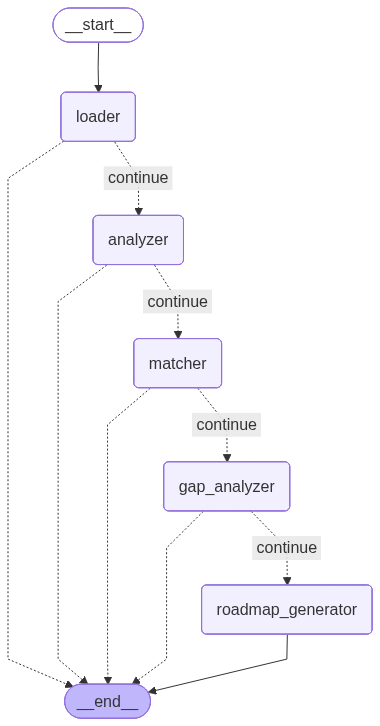

In [7]:
from IPython.display import Image, display

# ─────────────────────────────────────────────
#  Conditional Router: Skip downstream nodes on error
# ─────────────────────────────────────────────
def should_continue(state: AgentState) -> str:
    """Routes to END if an error was set upstream, otherwise continues."""
    return END if state.get("error") else "continue"


# ─────────────────────────────────────────────
#  Build the Graph
# ─────────────────────────────────────────────
workflow = StateGraph(AgentState)

# Register nodes
workflow.add_node("loader",           extract_text_node)
workflow.add_node("analyzer",         analyze_resume_node)
workflow.add_node("matcher",          vector_search_node)
workflow.add_node("gap_analyzer",     gap_analysis_node)
workflow.add_node("roadmap_generator", roadmap_generator_node)

# Entry point
workflow.set_entry_point("loader")

# Edges with error-guard routing
workflow.add_conditional_edges(
    "loader",
    should_continue,
    {"continue": "analyzer", END: END}
)
workflow.add_conditional_edges(
    "analyzer",
    should_continue,
    {"continue": "matcher", END: END}
)
workflow.add_conditional_edges(
    "matcher",
    should_continue,
    {"continue": "gap_analyzer", END: END}
)
workflow.add_conditional_edges(
    "gap_analyzer",
    should_continue,
    {"continue": "roadmap_generator", END: END}
)
workflow.add_edge("roadmap_generator", END)

# Compile
app = workflow.compile()

# Visualize
image = app.get_graph().draw_mermaid_png()
display(Image(image))

In [8]:
final_state = app.invoke({"file_path": "Resume_akash_.pdf"})

# Surface any errors
if final_state.get("error"):
    print(f"❌ Pipeline failed: {final_state['error']}")
else:
    print("✅ Pipeline completed successfully.")

C:\Users\gurav\AppData\Local\Temp\ipykernel_17988\1680808049.py:64: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  embeddings = OllamaEmbeddings(model=os.getenv("MODEL_NAME", "qwen3-embedding:0.6b"))


❌ Pipeline failed: Vector Search Error: Error raised by inference endpoint: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/embeddings (Caused by NewConnectionError("HTTPConnection(host='localhost', port=11434): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))


In [41]:
import textwrap

def print_roadmap(state: AgentState) -> None:
    """Renders the career roadmap in a readable format."""
    roadmap = state.get("roadmap", {})
    profile = state.get("profile")
    
    if not roadmap:
        print("No roadmap available.")
        return

    print("=" * 70)
    print(f"  PERSONALIZED CAREER ROADMAP")
    print(f"  Seniority: {roadmap.get('seniority_level')}")
    print(f"  Total Timeline: {roadmap.get('total_timeline')}")
    print("=" * 70)
    print(f"\n📊 MARKET OUTLOOK\n{roadmap.get('market_outlook')}")

    print(f"\n🔢 RECOMMENDED LEARNING SEQUENCE:")
    for i, skill in enumerate(roadmap.get("learning_sequence", []), 1):
        print(f"   {i}. {skill}")

    for step in roadmap.get("action_plan", []):
        badge = "🔴 CRITICAL" if step["importance"] == "Critical Gap" else "🟡 COMPETITIVE EDGE"
        print(f"\n{'─' * 70}")
        print(f"  {badge}  |  {step['skill'].upper()}  |  {step['time_estimate']}")
        print(f"{'─' * 70}")
        print(f"\n📌 Why it matters:\n   {step['why_it_matters']}")
        print(f"\n⚡ Leverage from your background:\n   {step['leverage_from_background']}")

        print(f"\n📚 RESOURCES:")
        for r in step.get("resources", []):
            free_tag = "[FREE]" if r.get("is_free") else "[PAID]"
            print(f"   {free_tag} {r['title']}")
            print(f"         → {r['url']}  ({r.get('resource_type', '')})")

        print(f"\n📅 WEEK-BY-WEEK PLAN:")
        for week in step.get("weekly_breakdown", []):
            print(f"\n   [{week['week_label']}] — {week['topic']}")
            for task in week.get("tasks", []):
                print(f"     • {task}")
            print(f"     ✅ Milestone: {week['milestone']}")

        print(f"\n🚀 CAPSTONE PROJECT:")
        print(textwrap.fill(f"   {step['capstone_project']}", width=68, subsequent_indent="   "))

        print(f"\n📝 RESUME BULLET:")
        print(textwrap.fill(f"   {step['resume_bullet']}", width=68, subsequent_indent="   "))

    print(f"\n{'=' * 70}")


print_roadmap(final_state)

  PERSONALIZED CAREER ROADMAP
  Seniority: Mid-level
  Total Timeline: 24-30 weeks

📊 MARKET OUTLOOK
These skills are critical for Blockchain Developer, Full Stack Developer, Backend Developer, and Data Analyst roles as they enable the development of scalable, secure, and efficient systems. Mastering these skills will allow candidates to design and implement robust architectures, ensuring seamless data processing and analysis. By filling these skill gaps, candidates can significantly enhance their market value and career prospects.

🔢 RECOMMENDED LEARNING SEQUENCE:
   1. Java
   2. Distributed systems
   3. Microservices
   4. Kafka
   5. Kubernetes
   6. Angular

──────────────────────────────────────────────────────────────────────
  🔴 CRITICAL  |  JAVA  |  6 weeks at 2-3 hrs/day
──────────────────────────────────────────────────────────────────────

📌 Why it matters:
   Java is a critical skill for the candidate's target roles, including Blockchain Developer, Full Stack Developer, a